# Implementation of IA self-calibration (Ji 2020)

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
import scipy

In [3]:
file = np.load("data/nofz_back.npz")
zB = file['z']
nzs = file['nz']

In [4]:
nz_interp_list = []
for i in range(7):
    inz_interp = scipy.interpolate.interp1d(zB, nzs[i], kind='linear', fill_value=0, bounds_error=False)
    nz_interp_list.append(inz_interp)

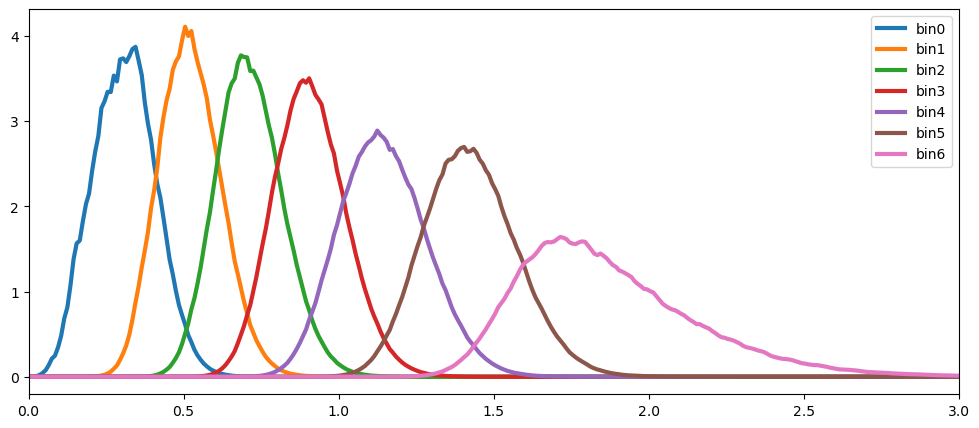

In [5]:
fig = plt.figure(figsize=(12,5))
for i in range(7):
    plt.plot(zB, nzs[i], lw=3, label='bin{}'.format(i))
plt.xlim(0,3)
plt.legend();

In [6]:
file = np.load("data/tomo_nz_hist2D.npz")
zp_edges = file['zp_edges']
z_edges = file['z_edges']
hist_zp_z = file['hist_zp_z']
hist_zp_z = hist_zp_z.T # H(i,j) = H(zpbin_i, zbin_j)
hist_zp_z_norm = hist_zp_z / (np.sum(hist_zp_z)*0.01**2)

In [7]:
zp_ctrs = 0.5*(zp_edges[1:] + zp_edges[:-1])
z_ctrs = 0.5*(z_edges[1:] + z_edges[:-1])

In [8]:
hist_zp_z.shape, zp_edges.shape

((400, 400), (401,))

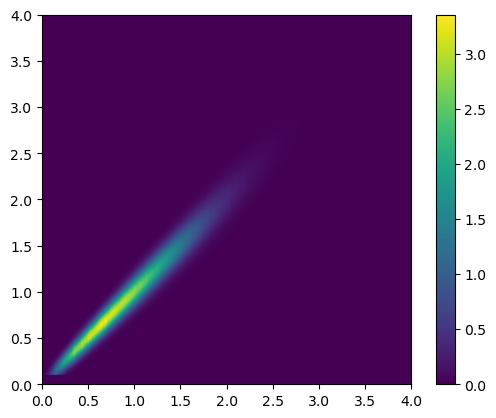

In [9]:
plt.imshow(hist_zp_z_norm, origin='lower', extent=(zp_edges[0], zp_edges[-1], z_edges[0], z_edges[-1]))
plt.colorbar();

In [10]:
p_z_zph_interp = scipy.interpolate.RegularGridInterpolator((zp_ctrs, z_ctrs), hist_zp_z_norm, bounds_error=False, fill_value=None)

### calculate $Q(\ell)$

\begin{equation}
    \int\mathrm{d}z_G^P\int\mathrm{d}z_g^P\int\mathrm{d}z_G W_L(z_L, z_G)p(z_G|z_G^P)p(z_g|z_g^P)p(z_g|z_g^P)S(z_G^P,z_g^P)n_i^P(z_G^P)n_i^P(z_g^P)
\end{equation}

In [11]:
import pyccl as ccl

In [12]:
cosmo_ccl = ccl.CosmologyVanillaLCDM()

In [13]:
sol = 2.99792458*1e5

In [14]:
## W_L
## z_S is z_G
def W_L(z_L, z_S, cosmo:ccl.Cosmology):
    chi_L = ccl.comoving_angular_distance(cosmo=cosmo, a=1./(1+z_L)) # Mpc
    chi_S = ccl.comoving_angular_distance(cosmo=cosmo, a=1./(1+z_S)) # Mpc
    OmegaM = cosmo.omega_x(a=1.0, species='matter')
    return (1.5*OmegaM*(cosmo_ccl["h"]*100)**2/sol**2 * (1 + z_L)*chi_L*(1 - chi_L/chi_S))*np.heaviside(z_S-z_L, 0)

In [15]:
import functools

In [16]:
W_L_partial = functools.partial(W_L, cosmo=cosmo_ccl)

In [17]:
def K_kernel(z_G, z_g, zp_G, zp_g, p_z_zph_func, nz_func):
    K_val = p_z_zph_func((zp_G, z_G)) * p_z_zph_func((zp_g, z_g)) * nz_func(zp_G) * nz_func(zp_g)
    return K_val

In [18]:
K_kernel_partial = functools.partial(K_kernel, p_z_zph_func=p_z_zph_interp, nz_func=nz_interp_list[2])

In [19]:
from joblib import Parallel, delayed

In [30]:
zp_min = 0.6
zp_max = 0.8
nz_interp_func = nz_interp_list[2]

z_L_rng = np.linspace(1e-5, 3.0, 256)
zp_G_rng = np.linspace(zp_min, zp_max, 1000)
zp_g_rng = np.linspace(zp_min, zp_max, 1000)
z_G_rng = np.linspace(1e-5, 100, 1000)

p_z_zph_zp_zG_grid = p_z_zph_interp(
    np.stack(
        np.meshgrid(zp_G_rng, z_G_rng, indexing='ij'),
        axis=-1
    )
)
p_z_zph_zpg_zL_grid = p_z_zph_interp(
    np.stack(
        np.meshgrid(zp_g_rng, z_L_rng, indexing='ij'),
        axis=-1
    )
)

A_int = np.empty((z_L_rng.shape[0], zp_G_rng.shape[0])) ## (z_L, zp_G)
B_int = np.empty((z_L_rng.shape[0], zp_G_rng.shape[0])) ## (z_L, zp_G)
eta_Gg = np.empty(z_L_rng.shape[0])
eta_Ig = np.empty(z_L_rng.shape[0])
nz_zp_G = nz_interp_func(zp_G_rng)
nz_zp_g = nz_interp_func(zp_g_rng)

In [31]:
def compute_eta_Gg_for_z_L(i, z_L):
    A_row = np.empty(zp_G_rng.shape[0])
    B_row = np.empty(zp_G_rng.shape[0])
    C_row = np.empty(zp_G_rng.shape[0])
    W_L_zG = W_L_partial(z_L, z_G_rng)
    p_z_zph_zpg_zL = p_z_zph_zpg_zL_grid[:, i]

    for j, zp_G in enumerate(zp_G_rng):
        A_row[j] = scipy.integrate.simpson(
            W_L_zG * p_z_zph_zp_zG_grid[j, :],
            x=z_G_rng
        )

        B_row[j] = scipy.integrate.simpson(
            p_z_zph_zpg_zL * nz_zp_g * np.heaviside(zp_g_rng - zp_G, 0),
            x=zp_g_rng
        )

        C_row[j] = scipy.integrate.simpson(
            p_z_zph_zpg_zL * nz_zp_g,
            x=zp_g_rng
        )

    eta_val_nom = 2*scipy.integrate.simpson(
        nz_zp_G * A_row * B_row,
        x=zp_G_rng
    )
    eta_val_denom = scipy.integrate.simpson(
        nz_zp_G * A_row * C_row,
        x=zp_G_rng
    )
    eta_val = np.divide(eta_val_nom, eta_val_denom, out=np.zeros_like(eta_val_nom), where=(eta_val_denom != 0))
    return i, eta_val

def compute_eta_Ig_for_z_L(i, z_L):
    A_row = np.empty(zp_G_rng.shape[0])
    B_row = np.empty(zp_G_rng.shape[0])
    C_row = np.empty(zp_G_rng.shape[0])
    p_z_zph_zpg_zL = p_z_zph_zpg_zL_grid[:, i]

    for j, zp_G in enumerate(zp_G_rng):
        A_row[j] = scipy.integrate.simpson(
            p_z_zph_zp_zG_grid[j, :],
            x=z_G_rng
        )

        B_row[j] = scipy.integrate.simpson(
            p_z_zph_zpg_zL * nz_zp_g * np.heaviside(zp_g_rng - zp_G, 0),
            x=zp_g_rng
        )

        C_row[j] = scipy.integrate.simpson(
            p_z_zph_zpg_zL * nz_zp_g,
            x=zp_g_rng
        )

    eta_val_nom = 2*scipy.integrate.simpson(
        nz_zp_G * A_row * B_row,
        x=zp_G_rng
    )
    eta_val_denom = scipy.integrate.simpson(
        nz_zp_G * A_row * C_row,
        x=zp_G_rng
    )
    eta_val = np.divide(eta_val_nom, eta_val_denom, out=np.zeros_like(eta_val_nom), where=(eta_val_denom != 0))
    return i, eta_val

In [32]:
%%time
results = Parallel(n_jobs=16)(
    delayed(compute_eta_Gg_for_z_L)(i, z_L)
    for i, z_L in enumerate(z_L_rng)
)

for i, eta_val in results:
    eta_Gg[i] = eta_val

CPU times: user 490 ms, sys: 225 ms, total: 715 ms
Wall time: 5.25 s


In [33]:
%%time
results = Parallel(n_jobs=16)(
    delayed(compute_eta_Ig_for_z_L)(i, z_L)
    for i, z_L in enumerate(z_L_rng)
)

for i,eta_val in results:
    eta_Ig[i] = eta_val

CPU times: user 199 ms, sys: 45.6 ms, total: 245 ms
Wall time: 3.41 s


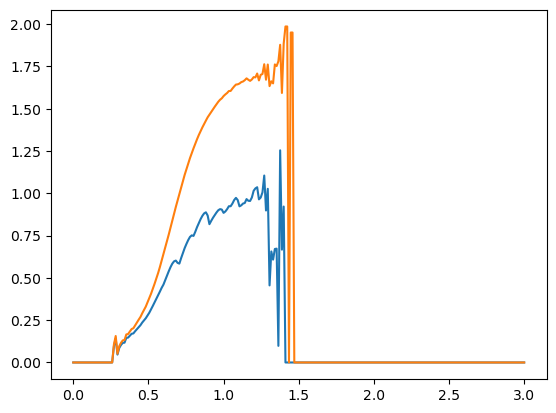

In [34]:
plt.plot(z_L_rng, eta_Gg)
plt.plot(z_L_rng, eta_Ig)

In [35]:
wl = ccl.WeakLensingTracer(cosmo=cosmo_ccl, dndz=(z_L_rng, nz_interp_func(z_L_rng)))
nc = ccl.NumberCountsTracer(cosmo=cosmo_ccl, dndz=(z_L_rng, nz_interp_func(z_L_rng)), bias=(z_L_rng, np.ones_like(z_L_rng)), has_rsd=False)
nc_etaGg = ccl.NumberCountsTracer(cosmo=cosmo_ccl, dndz=(z_L_rng, nz_interp_func(z_L_rng)), bias=(z_L_rng, np.ones_like(z_L_rng)*eta_Gg), has_rsd=False)
nc_etaIg = ccl.NumberCountsTracer(cosmo=cosmo_ccl, dndz=(z_L_rng, nz_interp_func(z_L_rng)), bias=(z_L_rng, np.ones_like(z_L_rng)*eta_Ig), has_rsd=False)

In [36]:
def NLA_model(z, A_IA, cosmo):
    C1 = 5e-14
    rhoc0 = 2.7750 * 1e11
    OmegaM = cosmo.omega_x(a=1.0, species='matter')
    Da = ccl.growth_factor(a=1./(1+z), cosmo=cosmo)
    return -A_IA * C1 * rhoc0 * OmegaM / Da

In [37]:
nc_IA = ccl.NumberCountsTracer(cosmo=cosmo_ccl, dndz=(z_L_rng, nz_interp_func(z_L_rng)), bias=(z_L_rng, NLA_model(z_L_rng, A_IA=0.6, cosmo=cosmo_ccl)), has_rsd=False)

In [38]:
wl_IA = ccl.WeakLensingTracer(cosmo=cosmo_ccl, dndz=(z_L_rng, nz_interp_func(z_L_rng)), ia_bias=(z_L_rng, np.ones_like(z_L_rng)*0.6), use_A_ia=True)

In [39]:
ell = np.geomspace(1.001, 1e4, 256)

In [40]:
C_Gg = ccl.angular_cl(cosmo=cosmo_ccl, tracer1=nc, tracer2=wl, ell=ell)
C_Ig = ccl.angular_cl(cosmo=cosmo_ccl, tracer1=nc, tracer2=nc_IA, ell=ell)

In [41]:
C_Gg_Select = ccl.angular_cl(cosmo=cosmo_ccl, tracer1=nc_etaGg, tracer2=wl, ell=ell)
C_Ig_Select = ccl.angular_cl(cosmo=cosmo_ccl, tracer1=nc_etaIg, tracer2=nc_IA, ell=ell)

Text(0, 0.5, '$Q(\\ell)$')

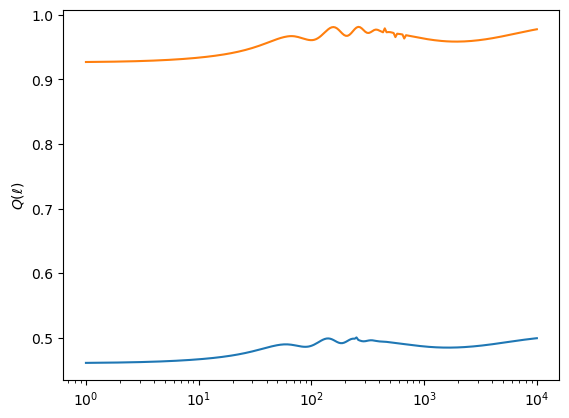

In [42]:
plt.semilogx(ell, C_Gg_Select/C_Gg)
plt.semilogx(ell, C_Ig_Select/C_Ig)
plt.ylabel(r'$Q(\ell)$')